In [ ]:
import numpy as np
import pandas as pd
import scipy
from scipy.stats import norm
from sklearn import mixture
import random

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

#import itertools
#from concurrent.futures import ThreadPoolExecutor, as_completed
from joblib import delayed, Parallel
from tqdm import tqdm
import pickle

In [ ]:
# The function of sampling GMM data points.
def sample_GMM(w, mu, sig, n):
    # Initialize variables
    K = len(w)
    x = np.zeros(n)
    # Sample from a Gaussian Mixture Model
    for j in range(n):
        comp = np.random.choice(K, p=w)
        x[j] = np.random.normal(mu[comp], sig[comp])

    return x

# The function of updating GMM parameters via EM.
def post_EM(x, w0, mu0, sig0, n, eps):
    # Initialize variables
    n_gmm_components = len(w0)
    n_data = len(x)
    w = np.copy(w0)
    zeros = np.where(w == 0)[0]
    w[zeros] = eps
    mu = np.copy(mu0)
    sig = np.copy(sig0)

    # Run EM algorithm n times
    for j in range(n):
        pr = np.zeros((n_gmm_components, n_data))
        for i, data in enumerate(x):
            tot = np.sum(w * norm.pdf(data, mu, sig))
            for k in range(n_gmm_components):
                pr[k, i] = (w[k] * norm.pdf(data, mu[k], sig0[k])) / tot

        nn = np.sum(pr, axis=1).clip(max=1/eps, min=eps)
        nn[np.isnan(nn)] = 0

        if np.sum(nn) != 0:
            vv = np.zeros(n_gmm_components)
            for k in range(n_gmm_components):
                if nn[k] == 0:
                    vv[k] = 1 / eps
                    continue

                vv[k] = np.sum(pr[k, :] * (x - mu[k])**2) / nn[k]

            vv[vv > (1 / eps)] = 1 / eps
            vv[vv==0]=eps
            ww = nn / n_data
            ww[ww == 0] = eps
            w = ww
            sig = vv

    w /= np.sum(w)

    return w, mu0, sig

In [ ]:
# Distance between GMMs.
# In our current experiment, only \pi (the weights) are updated, so the distance is simply the norm of diff.
def d_gmm(w1,w2):
    return np.linalg.norm(w1-w2)


# The function of generating N*N distance matrix.
def D_gmm(W):
    D = np.zeros((len(W),len(W)))
    for i in range(len(W)-1):
        for j in range(i+1,len(W)):
            D[i][j] = d_gmm(W[i], W[j])
            D[j][i] = D[i][j]
    return D


def get_data(weights_list, means_list, sigma_list, n_samples_per_interaction):
    data_list = []
    for i in range(n_models):
        data_list.append(sample_GMM(weights_list[i], gmm_means[i], gmm_sigmas[i], n_samples_per_interaction))
    data_list=np.array(data_list)

    return data_list


def _get_interaction_data(D, data_list, p_mirror, n_neighbors, i):
    coin = np.random.uniform(0,1,1)[0]
    if coin<p_mirror:
        data = data_list[i]
    else:
        sort = list(D[i].argsort())
        sort.remove(i)
        j = random.choice(sort[:n_neighbors])
        data = data_list[j]
    return data

def get_interaction_index(D, p_mirror, n_neighbors, i):
    coin = np.random.uniform(0,1,1)[0]
    if coin<p_mirror:
        return i
    else:
        sort = list(D[i].argsort())
        sort.remove(i)
        j = random.choice(sort[:n_neighbors])
        return j


def interaction(data, weights, means, sigmas, n_em_steps, eps=1e-12):
    w, _, _ = post_EM(data, weights, means, sigmas, n_em_steps, eps)

    return w

def update_qrag(qrag, X):
    # What are the dimensions of v_list? May need to transpose
    diff = np.abs(qrag - X)
    #diff = np.linalg.norm(qrag - X, axis=1) # only for multidimensional
    max_idx = np.argmax(diff)
    qrag[max_idx] = X
    return qrag


def system_of_interacting_gmms(T, n_models, interaction_parameters, initial_gmm_parameters, acorn=None):
    if acorn is not None:
        np.random.seed(acorn)

    p_mirror, n_neighbors, n_samples_per_interaction, n_em_steps = interaction_parameters
    gmm_weights, gmm_means, gmm_sigmas = initial_gmm_parameters


    gmm_weights_history = [gmm_weights]

    qrag = get_data(gmm_weights, gmm_means, gmm_sigmas, n_samples_per_interaction)

    qrag_history = [qrag]
    for t in range(T):
        # Step 1b
        gmm_weights_pp = []
        for i in range(n_models):
            data = qrag_history[-1]
            w = interaction(data[i], gmm_weights_history[-1][i], gmm_means[i], gmm_sigmas[i], n_em_steps, eps=1e-12)
            gmm_weights_pp.append(w)

        # Step 2
        X = get_data(gmm_weights_pp, gmm_means, gmm_sigmas, 1)

        D = D_gmm(gmm_weights_history[-1])
        if t==0:
            jitter = np.random.uniform(-0.01,0.01,(len(D),len(D)))
            jitter = jitter@jitter.T
            np.fill_diagonal(jitter,0)
            D = D + jitter

        gmm_weights_temp = []
        qrag_temp = []
        for i in range(n_models):
            j = get_interaction_index(D, p_mirror, n_neighbors, i)
            # Step 3
            qrag_cls_j = update_qrag(np.copy(qrag_history[-1][j]), X[i][0])

            # Step 4
            gmm_weights_clsup_j = interaction(qrag_cls_j, gmm_weights_history[-1][j], gmm_means[j], gmm_sigmas[j], n_em_steps, eps=1e-12)
            Y_clsup_j = sample_GMM(gmm_weights_clsup_j, gmm_means[j], gmm_sigmas[j], 1)

            # Step 5
            new_qrag = update_qrag(np.copy(qrag_history[-1][i]), Y_clsup_j[0])
            qrag_temp.append(new_qrag)
            w = interaction(new_qrag, gmm_weights_history[-1][i], gmm_means[i], gmm_sigmas[i], n_em_steps, eps=1e-12)
            gmm_weights_temp.append(w)
        qrag_history.append(qrag_temp)
        gmm_weights_history.append(gmm_weights_temp)

    return gmm_weights_history

### Code for a specific case

"\nIDs = []\nfor t in range(T+1):\n    ids = []\n    for i in range(n_models):\n        ids.append(np.argmax(gmm_weights_history[t][i]))\n    IDs.append(ids)\nIDs = pd.DataFrame(IDs)\n\n# Plotting the first component vs time for each agent.\n#df = pd.DataFrame(np.array(gmm_weights_history)[:, :, 0])\n#df.plot(y=df.columns, legend=False, xlabel='Time', ylabel='Weight of the first component')\n\n# ID plot.\nIDs.plot(y=IDs.columns, legend=False, xlabel='Time', ylabel='IDs')\nplt.title('ID vs Time, p=0.1, k=1, RAG size = 10')\n"

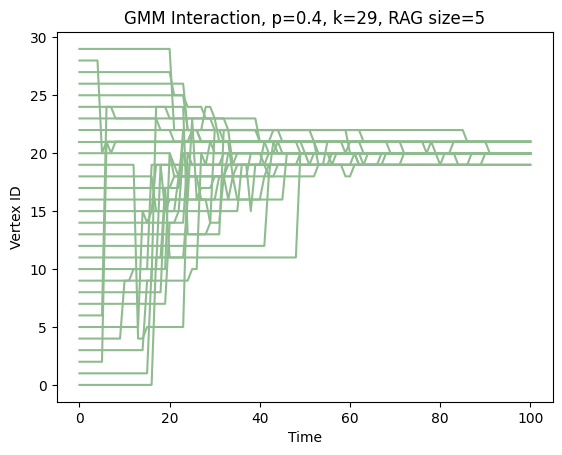

In [ ]:
np.random.seed(1)
T = 100

#- agent things
n_models = 30
#gmm_means = np.array([np.array([-1, 1]) for i in range(n_models)])
gmm_means = np.array([np.arange(0,n_models) for i in range(n_models)])
n_gmm_components=len(gmm_means[0])

gmm_sigmas = np.ones((n_models,n_gmm_components))/5
#gmm_weights = []
#for i in range(n_models):
    #gmm_weights.append(np.random.dirichlet(np.ones(n_gmm_components),size=1)[0])
#gmm_weights = np.array(gmm_weights)

gmm_weights = np.identity(n_models) # LLM experiment gmm initial weights
#gmm_weights = np.ones((n_models, n_gmm_components))/n_gmm_components # Avanti gmm initial weights

#- interaction mechanics
p_mirror = 0.4
n_neighbors = 29
n_samples_per_interaction= 5 # size of RAG
n_em_steps= 1

interaction_parameters = (p_mirror, n_neighbors, n_samples_per_interaction, n_em_steps)
initial_gmm_parameters = (gmm_weights, gmm_means, gmm_sigmas)

gmm_weights_history = system_of_interacting_gmms(T, n_models, interaction_parameters, initial_gmm_parameters)

IDs = []
for t in range(T+1):
    ids = []
    for i in range(n_models):
        ids.append(np.argmax(gmm_weights_history[t][i]))
    IDs.append(ids)
IDsunstable = pd.DataFrame(IDs)
ax = IDsunstable.plot(y=IDsunstable.columns, title=f'GMM Interaction, p={p_mirror}, k={n_neighbors}, RAG size={n_samples_per_interaction}', color=['darkseagreen']*30, legend=False, xlabel='Time', ylabel='Vertex ID')
"""
IDs = []
for t in range(T+1):
    ids = []
    for i in range(n_models):
        ids.append(np.argmax(gmm_weights_history[t][i]))
    IDs.append(ids)
IDs = pd.DataFrame(IDs)

# Plotting the first component vs time for each agent.
#df = pd.DataFrame(np.array(gmm_weights_history)[:, :, 0])
#df.plot(y=df.columns, legend=False, xlabel='Time', ylabel='Weight of the first component')

# ID plot.
IDs.plot(y=IDs.columns, legend=False, xlabel='Time', ylabel='IDs')
plt.title('ID vs Time, p=0.1, k=1, RAG size = 10')
"""

"\nIDs = []\nfor t in range(T+1):\n    ids = []\n    for i in range(n_models):\n        ids.append(np.argmax(gmm_weights_history[t][i]))\n    IDs.append(ids)\nIDs = pd.DataFrame(IDs)\n\n# Plotting the first component vs time for each agent.\n#df = pd.DataFrame(np.array(gmm_weights_history)[:, :, 0])\n#df.plot(y=df.columns, legend=False, xlabel='Time', ylabel='Weight of the first component')\n\n# ID plot.\nIDs.plot(y=IDs.columns, legend=False, xlabel='Time', ylabel='IDs')\nplt.title('ID vs Time, p=0.1, k=1, RAG size = 10')\n"

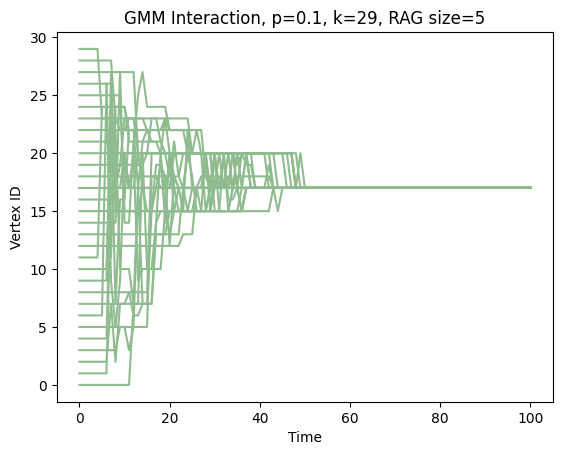

In [ ]:
np.random.seed(1)
T = 100

#- agent things
n_models = 30
#gmm_means = np.array([np.array([-1, 1]) for i in range(n_models)])
gmm_means = np.array([np.arange(0,n_models) for i in range(n_models)])
n_gmm_components=len(gmm_means[0])

gmm_sigmas = np.ones((n_models,n_gmm_components))/5
#gmm_weights = []
#for i in range(n_models):
    #gmm_weights.append(np.random.dirichlet(np.ones(n_gmm_components),size=1)[0])
#gmm_weights = np.array(gmm_weights)

gmm_weights = np.identity(n_models) # LLM experiment gmm initial weights
#gmm_weights = np.ones((n_models, n_gmm_components))/n_gmm_components # Avanti gmm initial weights

#- interaction mechanics
p_mirror = 0.1
n_neighbors = 29
n_samples_per_interaction= 5 # size of RAG
n_em_steps= 1

interaction_parameters = (p_mirror, n_neighbors, n_samples_per_interaction, n_em_steps)
initial_gmm_parameters = (gmm_weights, gmm_means, gmm_sigmas)

gmm_weights_history = system_of_interacting_gmms(T, n_models, interaction_parameters, initial_gmm_parameters)

IDs = []
for t in range(T+1):
    ids = []
    for i in range(n_models):
        ids.append(np.argmax(gmm_weights_history[t][i]))
    IDs.append(ids)
IDsstable = pd.DataFrame(IDs)
ax = IDsstable.plot(y=IDsstable.columns, title=f'GMM Interaction, p={p_mirror}, k={n_neighbors}, RAG size={n_samples_per_interaction}', color=['darkseagreen']*30, legend=False, xlabel='Time', ylabel='Vertex ID')
"""
IDs = []
for t in range(T+1):
    ids = []
    for i in range(n_models):
        ids.append(np.argmax(gmm_weights_history[t][i]))
    IDs.append(ids)
IDs = pd.DataFrame(IDs)

# Plotting the first component vs time for each agent.
#df = pd.DataFrame(np.array(gmm_weights_history)[:, :, 0])
#df.plot(y=df.columns, legend=False, xlabel='Time', ylabel='Weight of the first component')

# ID plot.
IDs.plot(y=IDs.columns, legend=False, xlabel='Time', ylabel='IDs')
plt.title('ID vs Time, p=0.1, k=1, RAG size = 10')
"""

(0.0, 1.0)

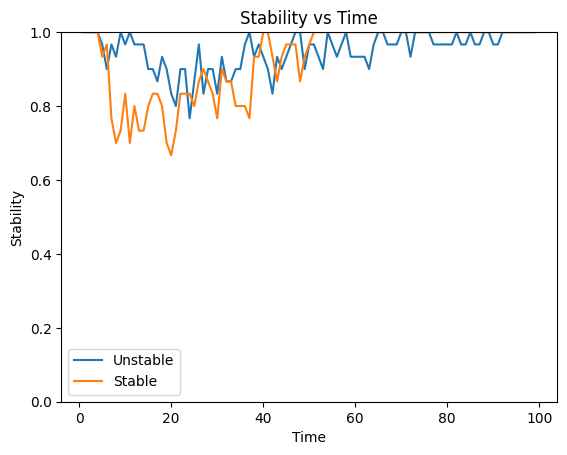

In [ ]:
#IDs = pd.DataFrame(IDs)
IDnpunstable = IDsunstable.to_numpy()
IDnpstable = IDsstable.to_numpy()
stability_unstable = []
stability_stable = []
count_unstable = []
count_stable = []
for t in range(0,T):
    count_unstable.append(len(set(IDnpunstable[t])))
    count_stable.append(len(set(IDnpstable[t])))
    if t != 0:
        stb = np.sum(IDnpunstable[t] == IDnpunstable[t-1])/30
        stability_unstable.append(stb)
        stb = np.sum(IDnpstable[t] == IDnpstable[t-1])/30
        stability_stable.append(stb)

#plt.plot(range(0,T), count)
plt.plot(range(1,T), stability_unstable, label='Unstable')
plt.plot(range(1,T), stability_stable, label='Stable')
plt.legend()
plt.title('Stability vs Time')
plt.xlabel('Time')
plt.ylabel('Stability')
plt.ylim(0, 1)


Text(0, 0.5, 'Number of Silos')

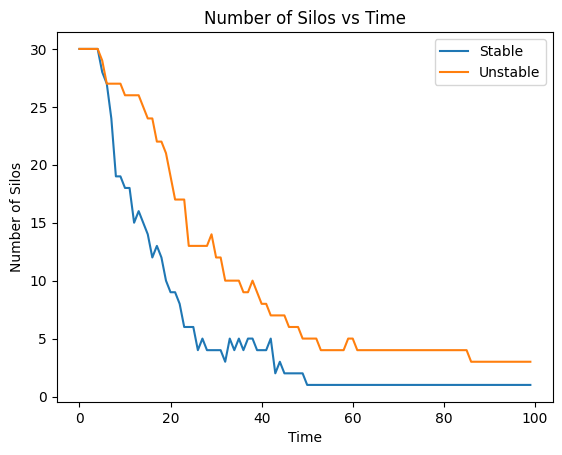

In [ ]:
plt.plot(range(0,T), count_stable, label='Stable')
plt.plot(range(0,T), count_unstable, label='Unstable')
plt.legend()
plt.title('Number of Silos vs Time')
plt.xlabel('Time')
plt.ylabel('Number of Silos')

Text(0, 0.5, 'Number of Agents in each Silo')

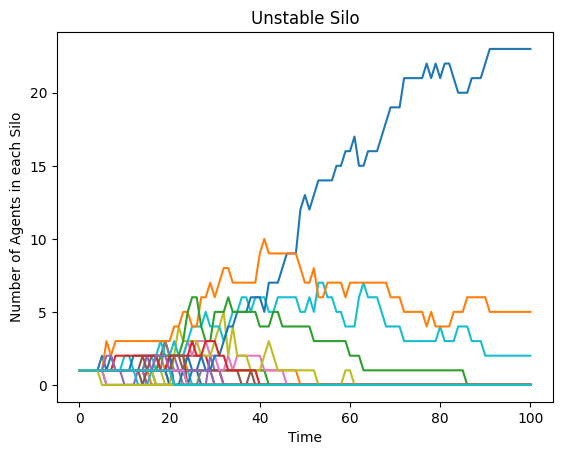

In [ ]:
# Elemetns in silo
for agent in range(30):
    agent_count = np.sum(IDnpunstable == agent, axis=1)
    plt.plot(range(0,T+1), agent_count, label=f'Agent {agent}')
plt.title('Unstable Silo')
plt.xlabel('Time')
plt.ylabel('Number of Agents in each Silo')

### Code for all cases, parallel coding.

In [ ]:
np.random.seed(1)
save_file = 'mirror.p'
generate=False

if generate:
    n_mc=5
    T=80

    n_model_list = [30]

    p_mirror_list = [0] #np.linspace(0,1, num=11)
    n_samples_per_interaction=10
    n_em_steps=1

    n_neighbors_list_dict = {30: [1,2,5,10,15,20,25,27,28,29]}

    parameter_dict = {}
    results_dict = {}

    for n_models in n_model_list:
        n_neighbors_list = n_neighbors_list_dict[n_models]

        gmm_means = np.array([np.arange(0,n_models) for i in range(n_models)])
        n_gmm_components=len(gmm_means[0])
        gmm_sigmas = np.ones((n_models,n_gmm_components))/5

        parameter_dict[n_models] = {}
        results_dict[n_models]={}
        for p_mirror in tqdm(p_mirror_list):
            parameter_dict[n_models][p_mirror] = {}
            results_dict[n_models][p_mirror]={}
            for n_neighbors in n_neighbors_list:
                interaction_parameters = (p_mirror, n_neighbors, n_samples_per_interaction, n_em_steps)

                parameter_list = []
                for _ in range(n_mc):
                    gmm_weights = np.identity(n_models)

                    initial_gmm_parameters = (gmm_weights, gmm_means, gmm_sigmas)
                    parameter_list.append(initial_gmm_parameters)


                f = lambda x: system_of_interacting_gmms(T, n_models, interaction_parameters, initial_gmm_parameters)

                parameter_dict[n_models][p_mirror][n_neighbors] = parameter_list
                results_dict[n_models][p_mirror][n_neighbors] = Parallel(n_jobs=-1)(delayed(f)(x) for x in parameter_dict[n_models][p_mirror][n_neighbors])

    pickle.dump(results_dict, open(save_file, 'wb'))
else:
    results_dict = pickle.load(open(save_file, 'rb'))